# Clasificación de la Madurez de la *Solanum betaceum* Cav

#1. Preparación del Dataset

##Normalización del formato de las imágenes

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/project-2-Berenjena.zip" -d /content/drive/MyDrive/project_Berenjena2

unzip:  cannot find or open /content/drive/MyDrive/project-2-Berenjena.zip, /content/drive/MyDrive/project-2-Berenjena.zip.zip or /content/drive/MyDrive/project-2-Berenjena.zip.ZIP.


In [ ]:
import os
from PIL import Image
from tqdm import tqdm  # Importamos tqdm para la barra de progreso

def convertir_y_redimensionar_imagenes(carpeta_origen, carpeta_destino, nuevo_ancho=640, nuevo_alto=640):
    # Verifica si la carpeta de destino existe, si no la crea
    if not os.path.exists(carpeta_destino):
        os.makedirs(carpeta_destino)

    # Listamos los archivos de imagen en la carpeta de origen
    archivos = [archivo for archivo in os.listdir(carpeta_origen) if os.path.isfile(os.path.join(carpeta_origen, archivo)) and
                archivo.lower().endswith(('.png', '.jpeg', '.bmp', '.gif', '.tiff', 'jpg','JPG'))]

    # Inicializamos un contador para numerar las imágenes
    contador = 1

    # Barra de progreso general
    with tqdm(total=len(archivos), desc="Procesando imágenes", unit="imagen") as pbar:
        for archivo in archivos:
            ruta_archivo = os.path.join(carpeta_origen, archivo)

            try:
                # Abre la imagen
                imagen = Image.open(ruta_archivo)

                # Redimensiona la imagen a 640x640
                imagen = imagen.resize((640, 640), Image.Resampling.LANCZOS)

                # Genera el nombre con un contador para que cada imagen tenga un nombre único
                nombre_salida = f"epp_{contador}.jpg"
                ruta_salida = os.path.join(carpeta_destino, nombre_salida)

                # Convierte y guarda la imagen como JPG
                imagen.convert('RGB').save(ruta_salida, 'jpg')

                # Incrementa el contador
                contador += 1
            except Exception as e:
                pass  # Ignorar errores y continuar procesando otras imágenes

            # Actualiza la barra de progreso
            pbar.update(1)

# Uso del script
carpeta_origen = "/content/drive/MyDrive/project_Berenjena2"   # Reemplaza con la ruta de tu carpeta de imágenes
carpeta_destino = "/content/drive/MyDrive/Data_Berenjena2" # Reemplaza con la ruta de la carpeta destino

convertir_y_redimensionar_imagenes(carpeta_origen, carpeta_destino)


#2. Etiquetado de las clases se realizó en Label-Studio

*   Elemento de la lista
*   Elemento de la lista



Las imagenes se procesaron en label-studio agregando la etiqueta correspondiente a cada clase.
Ejemplo del formato de los archivos:

```
0 0.217969 0.441667 0.091146 0.129630
0 0.332552 0.242593 0.043229 0.100000
0 0.291406 0.125463 0.031771 0.060185
0 0.238802 0.138426 0.031771 0.060185
0 0.297396 0.049074 0.023958 0.038889
0 0.320052 0.019907 0.017188 0.030556
0 0.465104 0.316204 0.055208 0.125000
0 0.495052 0.482407 0.067187 0.177778
0 0.141406 0.965278 0.116146 0.069444
```

En este caso:

- Cada fila corresponde a un objeto presente en la imagen. En total tendremos 9 filas y por tanto un total de 9 objetos
- Por cada objeto tendremos esta información: `class x_center y_center width height`.

Como en este caso queremos afinar el modelo para que detecte un solo tipo de objeto (0: vehículo) por tanto tendremos en todos los casos la categoría 0.

Observemos que las coordenadas del "bounding box" de cada objeto están normalizadas al tamaño de la imagen:

![](https://github.com/ultralytics/docs/releases/download/0/two-persons-tie.avif)

# 3. Estructura del Dataset

Según la documentación de Ultralytics, el set de imágenes debe estar estructurado de esta manera:

![](https://github.com/ultralytics/docs/releases/download/0/two-persons-tie-2.avif)



Además, usaremos el modelo más pequeño (YOLO11n) que contiene 2.6 millones de parámetros.

Estos son los pasos para tener disponible el set de datos desde Google Colab:

1. Primero debemos crear la carpeta "datasets" en el directorio "content" de Google Colab
2. Ahora descargamos el set de datos desde [este enlace](https://drive.google.com/file/d/15p5c3dGq3sm2bNUCevnHEOnwyC3MpE6L/view?usp=sharing).
3. Una vez descargado el archivo lo llevamos a la carpeta "datasets" de Google Colab
4. Ahora descomprimimos el archivo .zip:

##Creación de la lista de clases data.yaml

In [ ]:

import yaml

data = {
    'path': '/content/drive/MyDrive/project_Berenjena2',
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {
        0: "green fruit",
        1: "ripe fruit",
       }
}

with open('/content/drive/MyDrive/project_Berenjena2/data.yaml', 'w') as file:
    yaml.dump(data, file,
              default_flow_style=False,
              sort_keys=False)

#División del conjunto de datos entrenamiento, prueba y validación

In [ ]:
import os
import shutil
import random

# Rutas de las carpetas
base_dir = '/content/drive/MyDrive/project_Berenjena2'
images_dir = os.path.join(base_dir, 'images')
labels_dir = os.path.join(base_dir, 'labels')

# Subcarpetas de train, val y test
subfolders = ['train', 'val', 'test']
for subfolder in subfolders:
    os.makedirs(os.path.join(images_dir, subfolder), exist_ok=True)
    os.makedirs(os.path.join(labels_dir, subfolder), exist_ok=True)

# Obtener los nombres de las imágenes
image_files = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]

# Emparejar imagen con su archivo de etiqueta correspondiente
image_label_pairs = [(f, f.replace('.jpg', '.txt')) for f in image_files]

# Dividir en train, val y test (80%, 10%, 10%)
random.shuffle(image_label_pairs)
train_split = int(0.8 * len(image_label_pairs))
val_split = int(0.1 * len(image_label_pairs))

train_pairs = image_label_pairs[:train_split]
val_pairs = image_label_pairs[train_split:train_split + val_split]
test_pairs = image_label_pairs[train_split + val_split:]

# Función para mover las imágenes y sus etiquetas correspondientes
def move_files(pairs, subfolder):
    for image, label in pairs:
        # Mover imagen
        shutil.move(os.path.join(images_dir, image), os.path.join(images_dir, subfolder, image))
        # Mover archivo de etiqueta
        shutil.move(os.path.join(labels_dir, label), os.path.join(labels_dir, subfolder, label))

# Mover los archivos a las subcarpetas correspondientes
move_files(train_pairs, 'train')
move_files(val_pairs, 'val')
move_files(test_pairs, 'test')

print("Archivos organizados correctamente.")


Archivos organizados correctamente.


## 4. Entrenamiento del YOLO11 (detección) con el dataset

Para poder acceder al modelo pre-entrenado debemos comenzar instalando la librería "ultralytics":
Además, los modelos disponibles son los siguientes:

![](https://drive.google.com/uc?export=view&id=1PYaeIKj57C4_nys6XPAJrZ2tfdwiYEZQ)


En todos los casos la dimensión más grande a usar en las imágenes es de 640 pixeles, así que tendremos que ajustar las imágenes de nuestro set de datos a este tamaño.

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.8 MB/s eta 0:00:00


Posteriormente se debe entrenar el modelo:

1. Importar el modelo pre-entrenado
2. Usar el método "train" para realizar el entrenamiento

Por defecto en cada iteración de entrenamiento se almacenarán los pesos del modelo afinado en la carpeta "runs".

In [ ]:
from ultralytics import YOLO

# 1. Cargar el modelo (nano, el más pequeño)
model = YOLO("yolo11n.pt")

# Entrenar el modelo
results = model.train(data="/content/drive/MyDrive/project_Berenjena2/data.yaml",
                      epochs=100, # Número de iteraciones
                      imgsz=640, # Tamaño de las imágenes (máxima dimensión)
    # Batch
    batch=16,

    # Optimizador
    optimizer="AdamW",

    # Learning rate
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,

    # Regularización
    weight_decay=0.0005,

    # Warmup
    warmup_epochs=3,
    warmup_momentum=0.8,

    # Data augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,

    # Rendimiento
    cache="ram",
    workers=8,
    amp=True,

    # Guardado
    save=True,
    plots=True,
    verbose=True,

    # Nombre del experimento
    project="runs/train",
    name="YOLO11n_100")

In [ ]:

import time, math, yaml
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from ultralytics import YOLO

# ─────────────────────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────
DATA_YAML  = r"/content/drive/MyDrive/project_Berenjena2/data.yaml"
EPOCH_LIST = [100, 200, 300]
N_RUNS     = 4
OUTPUT_XLS = "yolo_resultados.xlsx"

BASE_PARAMS = dict(
    data=DATA_YAML, imgsz=640, batch=16,
    optimizer="AdamW", lr0=0.001, lrf=0.01, cos_lr=True,
    weight_decay=0.0005, warmup_epochs=3, warmup_momentum=0.8,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10, translate=0.1, scale=0.5, shear=2,
    perspective=0.0, flipud=0.0, fliplr=0.5,
    mosaic=1.0, mixup=0.1, copy_paste=0.1,
    cache="ram", workers=8, amp=True,
    save=True, plots=True, verbose=False,
    project="runs/train",
)

# ─────────────────────────────────────────────────────────────
# Leer clases y parámetros del modelo
# ─────────────────────────────────────────────────────────────
with open(DATA_YAML, "r") as f:
    _yaml = yaml.safe_load(f)
CLASS_NAMES = _yaml.get("names", [])
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[k] for k in sorted(CLASS_NAMES)]

def get_model_info(model):
    """Extrae GFLOPs y número de parámetros del modelo."""
    try:
        info = model.info(verbose=False)
        # info retorna (params, gflops) en algunas versiones
        if isinstance(info, (list, tuple)) and len(info) >= 2:
            params, gflops = info[0], info[1]
        else:
            # Alternativa: acceder directamente
            params = sum(p.numel() for p in model.model.parameters())
            gflops = getattr(model.model, 'flops', lambda: 0)() / 1e9
        return round(float(gflops), 1), f"{int(params):,}"
    except Exception:
        return "—", "—"

# ─────────────────────────────────────────────────────────────
# Extracción de métricas
# ─────────────────────────────────────────────────────────────
def extract_global(res, elapsed_s):
    m = res.results_dict if hasattr(res, 'results_dict') else {}
    return {
        "Precision": round(m.get("metrics/precision(B)", 0), 4),
        "Recall":    round(m.get("metrics/recall(B)",    0), 4),
        "mAP50":     round(m.get("metrics/mAP50(B)",     0), 4),
        "mAP50-95":  round(m.get("metrics/mAP50-95(B)",  0), 4),
        "Time":      round(elapsed_s / 60, 2),
    }

def extract_per_class(val_res, elapsed_s):
    """Devuelve dict {cls_name: {Precision, Recall, mAP50, mAP50-95, Time}}"""
    per_class = {}
    try:
        box     = val_res.box
        indices = val_res.ap_class_index.tolist()
        for i, cls_idx in enumerate(indices):
            name = CLASS_NAMES[cls_idx] if cls_idx < len(CLASS_NAMES) else f"class_{cls_idx}"
            per_class[name] = {
                "Precision": round(float(box.p[i]),    4),
                "Recall":    round(float(box.r[i]),    4),
                "mAP50":     round(float(box.ap50[i]), 4),
                "mAP50-95":  round(float(box.ap[i]),   4),
                "Time":      round(elapsed_s / 60, 2),
            }
    except Exception as e:
        print(f"  [aviso per-class]: {e}")
        # Fallback: usar métricas globales para todas las clases
        g = extract_global(val_res, elapsed_s)
        for name in CLASS_NAMES:
            per_class[name] = g
    return per_class

def extract_train_per_class(train_res, elapsed_s):
    """
    Train no devuelve per-class con la misma estructura que val.
    Intentamos extraerlo; si no, usamos métricas globales para todas las clases.
    """
    try:
        return extract_per_class(train_res, elapsed_s)
    except Exception:
        g = extract_global(train_res, elapsed_s)
        return {name: g for name in CLASS_NAMES}

# ─────────────────────────────────────────────────────────────
# Entrenamiento
# all_data[epochs][run][split][cls] = metrics_dict
# ─────────────────────────────────────────────────────────────
all_data    = {}
model_gflops = "—"
model_params = "—"

for epochs in EPOCH_LIST:
    all_data[epochs] = {}
    for run in range(1, N_RUNS + 1):
        name = f"YOLO11n_ep{epochs}_run{run}"
        print(f"\n{'='*60}")
        print(f"  Épocas={epochs}  |  Corrida {run}/{N_RUNS}")
        print(f"{'='*60}")

        model = YOLO("yolo11s.pt")

        # Obtener info del modelo una sola vez
        if model_gflops == "—":
            model_gflops, model_params = get_model_info(model)

        # Train
        t0 = time.time()
        train_res  = model.train(epochs=epochs, name=name, **BASE_PARAMS)
        train_time = time.time() - t0

        # Val
        t0 = time.time()
        val_res  = model.val(data=DATA_YAML, imgsz=640, split="val",  verbose=False)
        val_time = time.time() - t0

        # Test
        t0 = time.time()
        test_res  = model.val(data=DATA_YAML, imgsz=640, split="test", verbose=False)
        test_time = time.time() - t0

        all_data[epochs][run] = {
            "Train": extract_train_per_class(train_res, train_time),
            "Val":   extract_per_class(val_res,  val_time),
            "Test":  extract_per_class(test_res, test_time),
        }

# ─────────────────────────────────────────────────────────────
# Excel — estilos
# ─────────────────────────────────────────────────────────────
C_DARK   = "1F3864"
C_MID    = "2E75B6"
C_COL_H  = "4472C4"
C_TRAIN  = "D6E4F7"
C_VAL    = "E2EFDA"
C_TEST   = "FFF2CC"
C_AVG    = "F2DCDB"
C_STD    = "EDEDED"
C_WHITE  = "FFFFFF"
C_SUMHDR = "7030A0"
C_SUMCOL = "9E3AC5"

SPLIT_CLR = {"Train": C_TRAIN, "Val": C_VAL, "Test": C_TEST}
SPLIT_FC  = {"Train": "1F497D", "Val": "375623", "Test": "7F6000"}

thin   = Side(style="thin", color="BFBFBF")
B_THIN = Border(left=thin, right=thin, top=thin, bottom=thin)

def fill(h):  return PatternFill("solid", fgColor=h)
def fnt(bold=False, color="000000", size=10):
    return Font(bold=bold, color=color, size=size, name="Arial")
def ctr(): return Alignment(horizontal="center", vertical="center")
def lft(): return Alignment(horizontal="left",   vertical="center")

COLS   = ["Model","Clase","Split","Precision","Recall","mAP50","mAP50-95","Time (min)","GFLOPs","Parameters"]
N_COLS = len(COLS)

def wc(ws, r, c, v, bold=False, color="000000", bg=None, fmt=None, align="center"):
    cell = ws.cell(row=r, column=c, value=v)
    cell.font      = fnt(bold, color)
    cell.border    = B_THIN
    cell.alignment = ctr() if align == "center" else lft()
    if bg:  cell.fill          = fill(bg)
    if fmt: cell.number_format = fmt
    return cell

# ─────────────────────────────────────────────────────────────
# Construcción del workbook
# ─────────────────────────────────────────────────────────────
wb = openpyxl.Workbook()
wb.remove(wb.active)
ws = wb.create_sheet("Resultados")
ws.sheet_view.showGridLines = False

col_widths = [22, 16, 10, 13, 13, 13, 14, 13, 12, 18]
for i, w in enumerate(col_widths, 1):
    ws.column_dimensions[get_column_letter(i)].width = w

row = 1

for epochs in EPOCH_LIST:

    # Título bloque
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=N_COLS)
    c = ws.cell(row=row, column=1, value=f"YOLO11n — {epochs} Épocas — {N_RUNS} Corridas")
    c.font = fnt(True, C_WHITE, 12); c.fill = fill(C_DARK)
    c.alignment = ctr(); c.border = B_THIN
    ws.row_dimensions[row].height = 24; row += 1

    # Cabecera columnas
    for ci, name in enumerate(COLS, 1):
        wc(ws, row, ci, name, bold=True, color=C_WHITE, bg=C_COL_H)
    ws.row_dimensions[row].height = 20; row += 1

    # Acumulador para estadísticos
    accum = {sp: {cls: {k: [] for k in ["Precision","Recall","mAP50","mAP50-95","Time"]}
                  for cls in CLASS_NAMES}
             for sp in ["Train","Val","Test"]}

    for run in range(1, N_RUNS + 1):
        # Sub-cabecera corrida
        ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=N_COLS)
        c = ws.cell(row=row, column=1, value=f"Corrida {run}")
        c.font = fnt(True, C_WHITE, 10); c.fill = fill(C_MID)
        c.alignment = ctr(); c.border = B_THIN
        ws.row_dimensions[row].height = 18; row += 1

        for cls in CLASS_NAMES:
            for sp in ["Train","Val","Test"]:
                m  = all_data[epochs][run][sp].get(cls, {})
                bg = SPLIT_CLR[sp]
                fc = SPLIT_FC[sp]

                for k in ["Precision","Recall","mAP50","mAP50-95","Time"]:
                    val = m.get(k)
                    if isinstance(val, float):
                        accum[sp][cls][k].append(val)

                vals = [
                    "YOLO11n", cls, sp,
                    m.get("Precision","—"), m.get("Recall","—"),
                    m.get("mAP50","—"),     m.get("mAP50-95","—"),
                    m.get("Time","—"),
                    model_gflops, model_params,
                ]
                for ci, v in enumerate(vals, 1):
                    fmt_ = ("0.0000" if ci in (4,5,6,7) else
                            "0.00"   if ci == 8 else
                            "0.0"    if ci == 9 else None)
                    wc(ws, row, ci, v,
                       bold=(ci<=3), color=(fc if ci<=3 else "000000"),
                       bg=bg, fmt=fmt_, align=("left" if ci<=3 else "center"))
                ws.row_dimensions[row].height = 16; row += 1

    # ── Estadísticos ──────────────────────────────────────────
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=N_COLS)
    c = ws.cell(row=row, column=1,
                value=f"Estadísticos — {epochs} épocas  ({N_RUNS} corridas)")
    c.font = fnt(True, C_WHITE, 10); c.fill = fill(C_SUMHDR)
    c.alignment = ctr(); c.border = B_THIN
    ws.row_dimensions[row].height = 18; row += 1

    for ci, name in enumerate(COLS, 1):
        wc(ws, row, ci, name, bold=True, color=C_WHITE, bg=C_SUMCOL)
    ws.row_dimensions[row].height = 18; row += 1

    def std(xs):
        if not xs: return "—"
        mu = sum(xs)/len(xs)
        return round(math.sqrt(sum((x-mu)**2 for x in xs)/len(xs)), 4)
    def avg(xs):
        return round(sum(xs)/len(xs), 4) if xs else "—"

    for cls in CLASS_NAMES:
        for sp in ["Train","Val","Test"]:
            fc = SPLIT_FC[sp]
            for label, bg, fn in [("Promedio", C_AVG, avg), ("Desv. Estándar", C_STD, std)]:
                vals = [f"YOLO11n — {label}", cls, sp]
                for k in ["Precision","Recall","mAP50","mAP50-95","Time"]:
                    vals.append(fn(accum[sp][cls][k]))
                vals += [model_gflops, model_params]

                for ci, v in enumerate(vals, 1):
                    fmt_ = ("0.0000" if ci in (4,5,6,7) else
                            "0.00"   if ci == 8 else
                            "0.0"    if ci == 9 else None)
                    is_num = isinstance(v, float)
                    wc(ws, row, ci, v,
                       bold=(ci<=3), color=(fc if ci<=3 else "000000"),
                       bg=bg, fmt=(fmt_ if is_num else None),
                       align=("left" if ci<=3 else "center"))
                ws.row_dimensions[row].height = 16; row += 1

    row += 2  # separador entre bloques

ws.freeze_panes = "D3"
wb.save(OUTPUT_XLS)
print(f"\n✓ Excel guardado: {OUTPUT_XLS}")


  Épocas=100  |  Corrida 1/4
Ultralytics 8.4.79 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/project_Berenjena2/data.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11n_ep100_run1-4, nbs=64, nms=

In [ ]:
# prompt: A partir de estos resultados generales dar otras métricas como precisión, recal, F1-score y mAP50

# El entrenamiento del modelo YOLOv8 ya proporciona métricas
# como precision, recall, mAP (mean Average Precision)
# para diferentes IoU (Intersection over Union) thresholds.

# Si la variable 'results' contiene el objeto de resultados del entrenamiento,
# estas métricas se pueden acceder directamente.
# El entrenamiento con `plots=True` también guarda estos resultados
# en archivos dentro de la carpeta 'runs/detect/train<numeros>'.

# Para mostrar las métricas después del entrenamiento, si 'results'
# es el objeto de retorno del método .train(), puedes acceder a ellas.
# Las métricas typically están disponibles en el objeto results.
# La documentación de Ultralytics YOLOv8 (o en este caso YOLO11 si existe)
# detalla la estructura del objeto de resultados.

# Suponiendo que 'results' contiene el objeto de entrenamiento de Ultralytics
# Puedes acceder a las métricas guardadas o, si el objeto results las expone,
# directamente del objeto.

# Acceder a las métricas si están en el objeto 'results'
# Nota: La forma exacta de acceder a estas métricas puede variar ligeramente
# dependiendo de la versión específica de ultralytics que estés usando.
# Consulta la documentación de ultralytics para la versión de YOLO11 (si es un modelo real y no una errata por YOLOv8)
# o la versión de ultralytics que usaste.
# Para YOLOv8, las métricas de validación están en el objeto 'results' retornado por model.train()

# Intenta acceder a las métricas de validación:
try:
    # Acceder a las métricas de validación si están disponibles en el objeto results
    # Esto es común en las versiones más recientes de Ultralytics YOLO
    metrics = results.metrics  # Esto asume que el objeto results tiene un atributo metrics

    print("\nMétricas de Validación:")
    print(f"  Precision: {metrics.get('metrics/precision(B)') if metrics and 'metrics/precision(B)' in metrics else 'N/A'}")
    print(f"  Recall: {metrics.get('metrics/recall(B)') if metrics and 'metrics/recall(B)' in metrics else 'N/A'}")
    # F1-score no es una métrica directa del entrenamiento estándar de YOLO,
    # pero se puede calcular a partir de Precision y Recall si se tienen.
    # mAP50 es la métrica mean Average Precision con un umbral de IoU del 50%
    print(f"  mAP50: {metrics.get('metrics/mAP50(B)') if metrics and 'metrics/mAP50(B)' in metrics else 'N/A'}")
    # mAP50-95 es el promedio de mAP sobre umbrales de IoU del 50% al 95%
    print(f"  mAP50-95: {metrics.get('metrics/mAP50-95(B)') if metrics and 'metrics/mAP50-95(B)' in metrics else 'N/A'}")

    # Nota: Las claves exactas ('metrics/precision(B)', etc.) pueden variar ligeramente
    # o pueden estar organizadas de manera diferente dependiendo de la versión.
    # Verifica la estructura del objeto 'results.metrics' si el acceso directo falla.

except AttributeError:
    print("\nNo se pudo acceder a las métricas directamente desde el objeto 'results'.")
    print("Las métricas se guardan en los archivos dentro de la carpeta de entrenamiento.")
    print("Puedes encontrar los resultados detallados en: /content/runs/detect/train<número>/results.csv")

# Si el acceso directo falla, las métricas siempre se guardan en la carpeta de resultados
# Por defecto, Ultralytics guarda los resultados en runs/detect/train<número>
# Puedes encontrar un archivo llamado results.csv en esa carpeta
# Para obtener la ruta exacta, podrías necesitar inspeccionar la carpeta 'runs/detect'

# Ejemplo de cómo encontrar la carpeta de resultados más reciente (si se ejecutó model.train)
runs_dir = '/content/runs/detect'
if os.path.exists(runs_dir):
    # Obtener la lista de directorios dentro de runs/detect
    train_dirs = [d for d in os.listdir(runs_dir) if os.path.isdir(os.path.join(runs_dir, d)) and d.startswith('train')]
    if train_dirs:
        # Ordenar por nombre para obtener el más reciente (basado en la numeración)
        train_dirs.sort()
        latest_train_dir = os.path.join(runs_dir, train_dirs[-1])
        results_csv_path = os.path.join(latest_train_dir, 'results.csv')

        if os.path.exists(results_csv_path):
            print(f"\nLas métricas detalladas están disponibles en: {results_csv_path}")
            # Puedes leer el archivo CSV para obtener los valores finales
            # Esto requiere pandas o procesamiento manual del CSV
            import pandas as pd
            try:
                df_results = pd.read_csv(results_csv_path)
                # El archivo results.csv contiene las métricas por época y las finales
                # Las últimas filas suelen contener los resultados finales o promedio.
                # Necesitas identificar las columnas correspondientes a las métricas.
                # Las columnas suelen ser 'Metrics/Precision(B)', 'Metrics/Recall(B)', 'Metrics/mAP50(B)', etc.

                # Intenta encontrar las columnas relevantes y obtener el último valor (mejor o final)
                print("\nMétricas finales (desde results.csv):")
                if '  Metrics/Precision(B)' in df_results.columns:
                     print(f"  Precision: {df_results['  Metrics/Precision(B)'].iloc[-1]}")
                if '  Metrics/Recall(B)' in df_results.columns:
                     print(f"  Recall: {df_results['  Metrics/Recall(B)'].iloc[-1]}")
                if '  Metrics/mAP50(B)' in df_results.columns:
                     print(f"  mAP50: {df_results['  Metrics/mAP50(B)'].iloc[-1]}")
                if '  Metrics/mAP50-95(B)' in df_results.columns:
                     print(f"  mAP50-95: {df_results['  Metrics/mAP50-95(B)'].iloc[-1]}")

            except Exception as e:
                 print(f"Error al leer results.csv: {e}")
        else:
            print(f"\nNo se encontró el archivo results.csv en {latest_train_dir}")
    else:
        print("\nNo se encontraron carpetas de entrenamiento en /content/runs/detect.")
else:
    print("\nLa carpeta de resultados de entrenamiento (/content/runs/detect) no existe.")




No se pudo acceder a las métricas directamente desde el objeto 'results'.
Las métricas se guardan en los archivos dentro de la carpeta de entrenamiento.
Puedes encontrar los resultados detallados en: /content/runs/detect/train<número>/results.csv

Las métricas detalladas están disponibles en: /content/runs/detect/train/results.csv

Métricas finales (desde results.csv):


In [ ]:
import shutil

origen = "/content/runs/detect/runs"
destino = "/content/drive/MyDrive"

shutil.copytree(origen, destino, dirs_exist_ok=True)

'/content/drive/MyDrive'

In [ ]:
# prompt: A partir de estos resultados general otras metricas como la precision, recall, F1-score y mAP50

# The training of the YOLOv8 model already generates metrics such as precision, recall, F1-score, and mAP50.
# These results are stored in the 'results' variable after the training is completed.
# You can access them directly from the 'results' object or from the saved results file.

# Display the metrics obtained from the training
print("\nMétricas del entrenamiento:")

# The metrics are saved in the results.csv file within the run directory.
# The path to the results directory can be obtained from 'results.save_dir'.

# Path where the training results were saved
save_dir = results.save_dir
print(f"\nLos resultados detallados se guardaron en: {save_dir}")

# To view the detailed results (e.g., metrics.csv), you can read the file:
import pandas as pd
import os

metrics_path = os.path.join(save_dir, 'results.csv')

try:
    if os.path.exists(metrics_path):
        metrics_df = pd.read_csv(metrics_path)

        # The last row of the results.csv typically contains the final metrics
        final_metrics = metrics_df.iloc[-1]

        print("\nMétricas finales del entrenamiento:")
        print(f"Precision: {final_metrics['metrics/precision(B)']:.3f}")
        print(f"Recall: {final_metrics['metrics/recall(B)']:.3f}")
        # Calculate F1-score from precision and recall
        precision = final_metrics['metrics/precision(B)']
        recall = final_metrics['metrics/recall(B)']
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        print(f"F1-score: {f1_score:.3f}")
        print(f"mAP50: {final_metrics['metrics/mAP50(B)']:.3f}")
        print(f"mAP50-95: {final_metrics['metrics/mAP50-95(B)']:.3f}")

        # If you want to see the full dataframe with all epochs' metrics:
        # print("\nContenido completo de results.csv:")
        # display(metrics_df)

    else:
        print("\nEl archivo results.csv no se encontró en la carpeta de resultados.")
except Exception as e:
    print(f"\nError al leer results.csv: {e}")

# You can also access more detailed metrics if you run the 'val' method
# after training, although the 'train' method already does this at the end.
# If you wanted to validate with a different dataset or afterwards, you would do:
# val_results = model.val()
# print("\nMétricas obtenidas de una validación manual:")
# print(f"Precision: {val_results.results_dict['metrics/precision(B):']}")
# print(f"Recall: {val_results.results_dict['metrics/recall(B):']}")
# print(f"F1-score: {val_results.results_dict['metrics/f1(B):']}")
# print(f"mAP50: {val_results.results_dict['metrics/mAP50(B):']}")
# print(f"mAP50-95: {val_results.results_dict['metrics/mAP50-95(B):']}")


Métricas del entrenamiento:

Los resultados detallados se guardaron en: runs/detect/train

Métricas finales del entrenamiento:
Precision: 0.874
Recall: 0.851
F1-score: 0.862
mAP50: 0.906
mAP50-95: 0.680


Al realizar la afinación veremos impresas en pantalla varias métricas de las cuáles las más importantes son:

- "box_loss": mide el error en la ubicación y tamaño de los "bounding boxes" predichos en comparación con los de referencia. Se calcula como 1 - IntersectionOverUnion.
- "cls_loss": es el error en la clasificación del objeto dentro del "bounding box". Se calcula como la entropía cruzada
- "mAP": la precisión media que mide qué tan buenas detecciones genera el modelo (entre más cercano a 1 sea este valor mejor será el desempeño).

Después de unos minutos tendremos el modelo ya afinado. Este quedará almacenado en la carpeta `../runs/detect/train/weights/best.pt'`.

Podemos generar algunos gráficos del proceso de entrenamiento y validación para verificar que no haya "overfitting".

Por ejemplo grafiquemos las pérdidas para entrenamiento y validación:

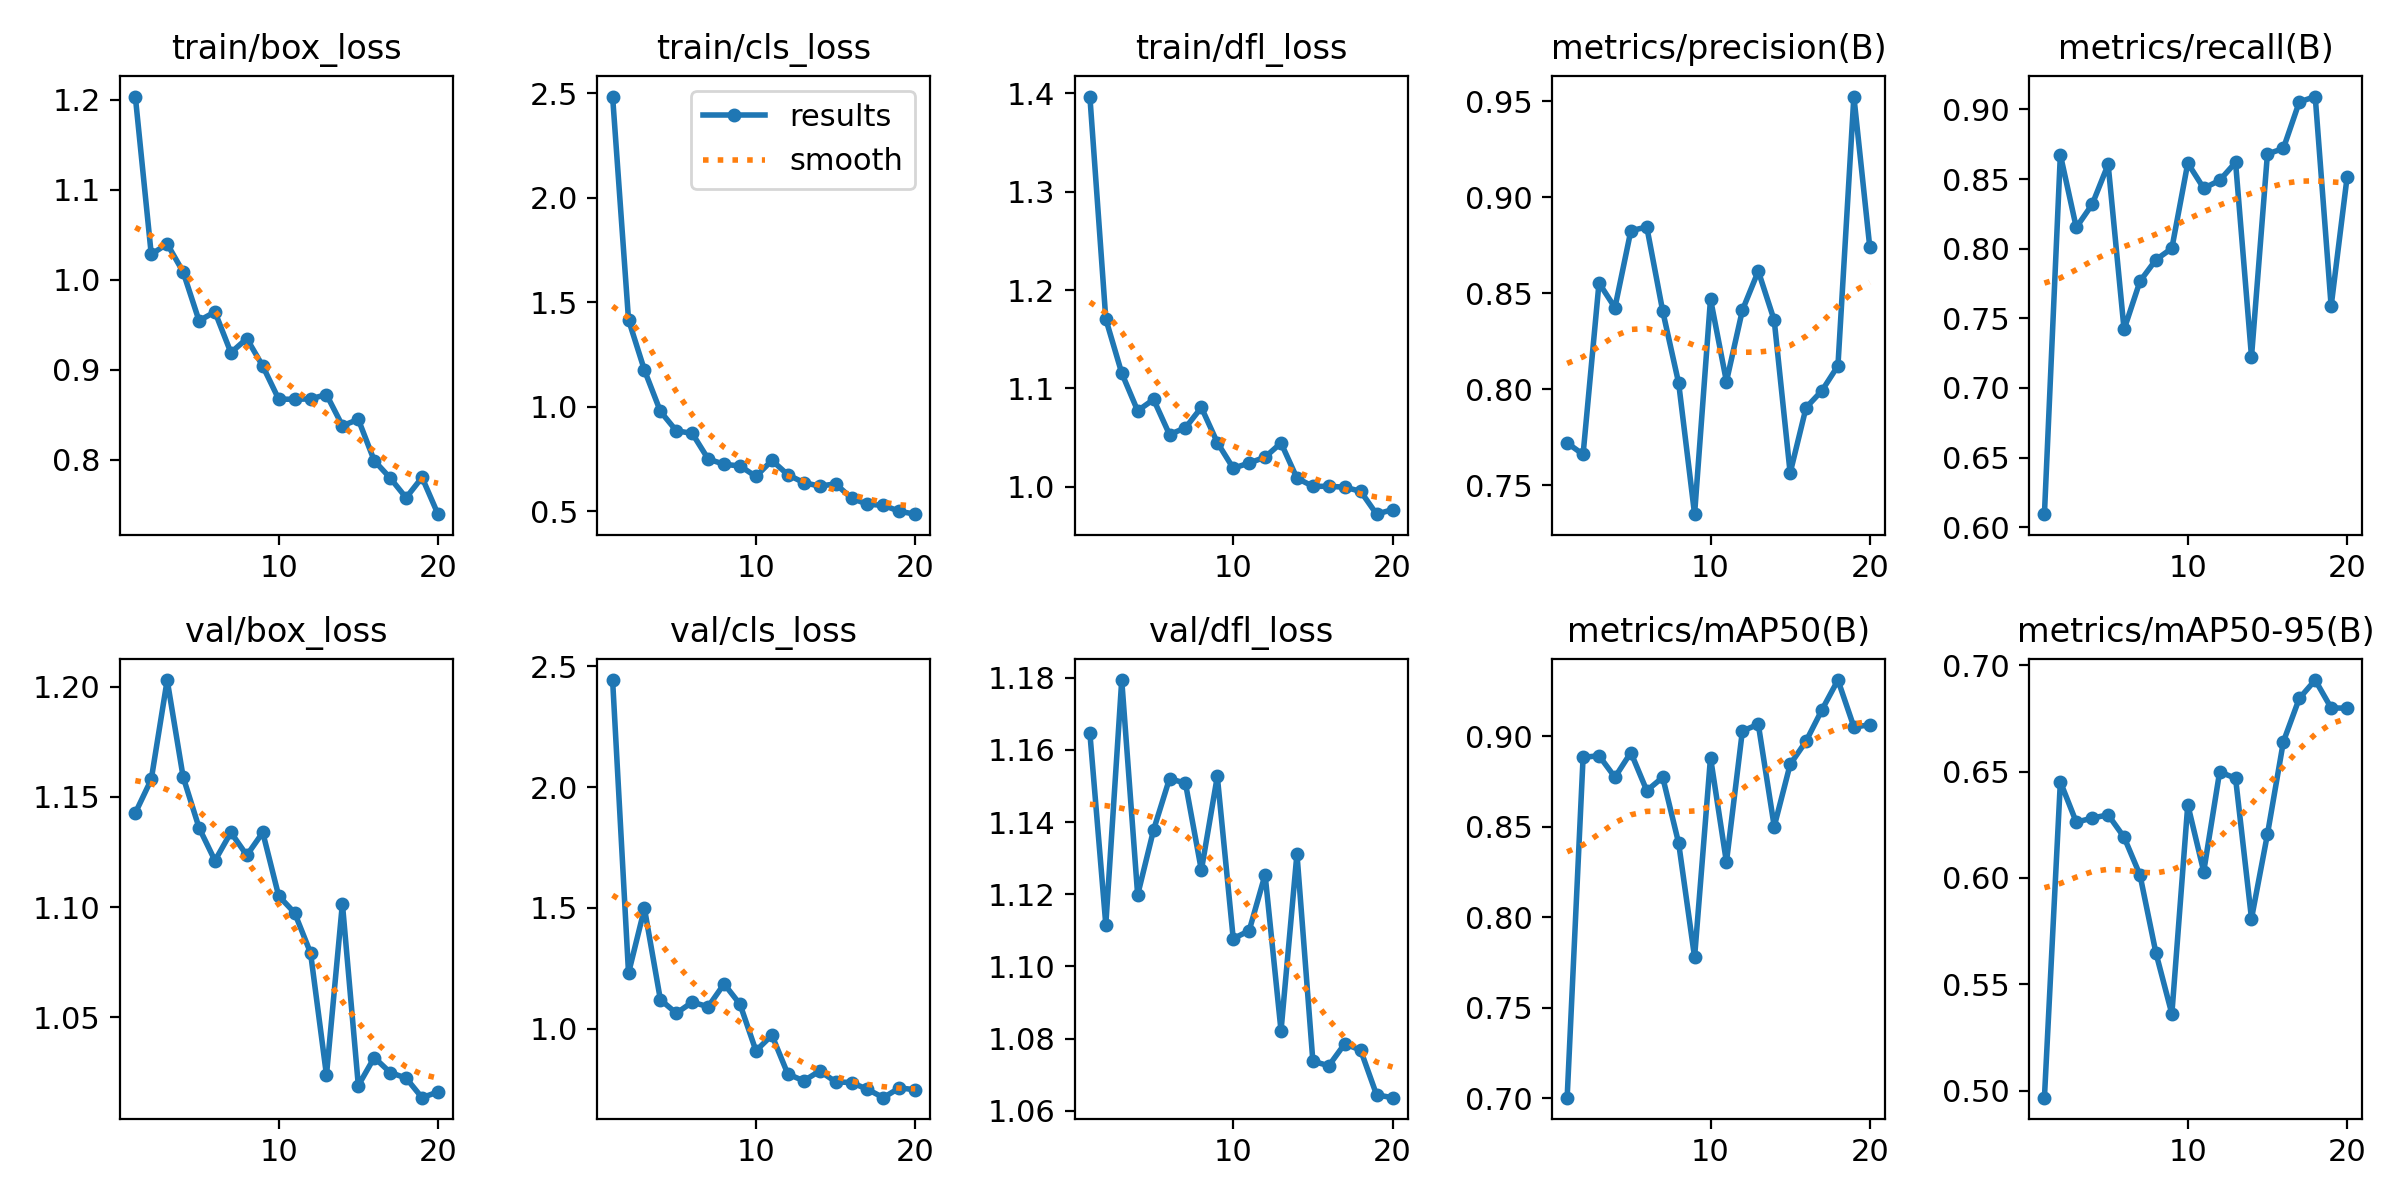

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename='/content/runs/detect/train2/results.png', width=800)

Y al observar estas gráficas vemos que convergen a valores muy cercanos tanto en entrenamiento como en validación y por tanto podemos concluir que el modelo afinado generaliza bastante bien.

Podemos ver el desempeño de la clasificación de los objetos (dentro del proceso de detección) graficando la matriz de confusión:

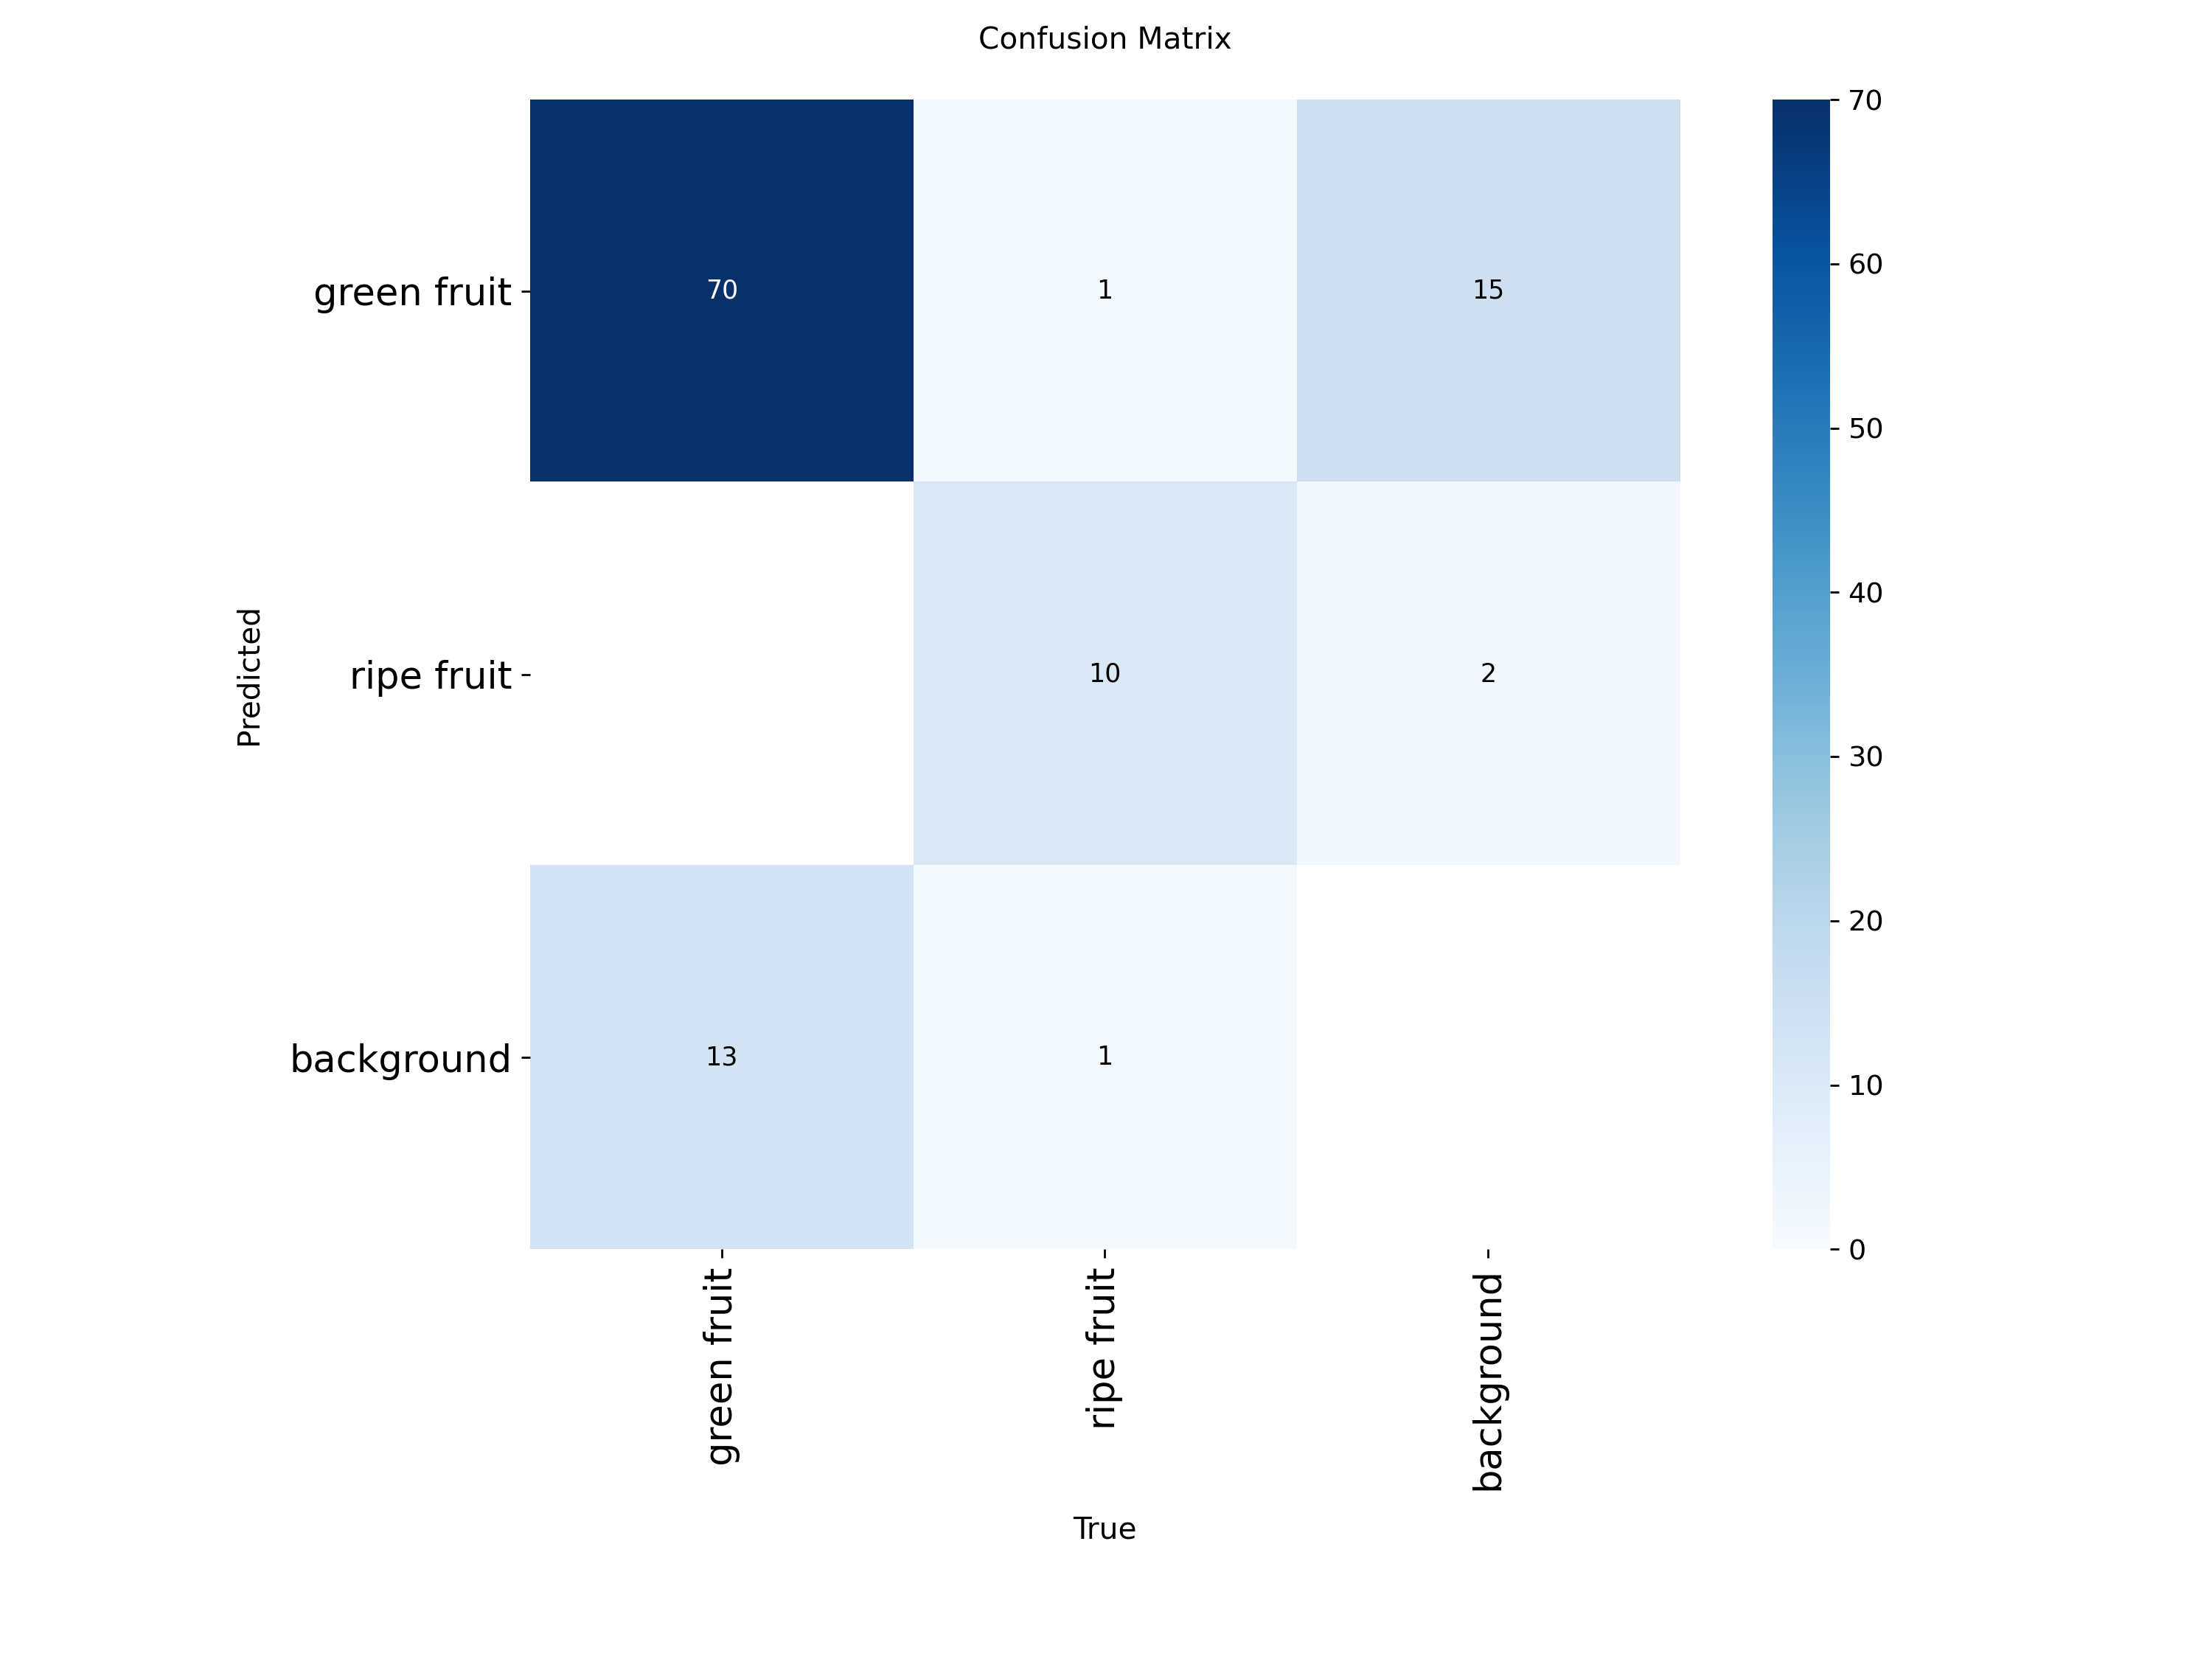

In [ ]:
IPyImage(filename='/content/runs/detect/train2/confusion_matrix.png', width=900)

## 5. Generación de predicciones con el modelo

Y por último, podemos usar el set de prueba (disponible en la carpeta `../datasets/dataset_vehiculos/images/test`) para generar predicciones sobre nuevos datos usando el modelo afinado.

Comencemos cargando el modelo afinado:

In [ ]:
model = YOLO('/content/runs/detect/train2/weights/best.pt')

NameError: name 'YOLO' is not defined

Y ahora generemos predicciones sobre la totalidad del set de prueba (50 imágenes):

In [ ]:
import shutil

ruta_origen = '/content/runs/detect/train2/weights/best.pt'
ruta_destino = '/content/drive/MyDrive/ModelosBerenjena/best.pt'  # Ajusta según tu estructura en Drive

shutil.move(ruta_origen, ruta_destino)
print(f'Archivo guardado drive: {ruta_destino}')

Archivo guardado drive: /content/drive/MyDrive/ModelosBerenjena/best.pt


In [ ]:
preds = model('/content/drive/MyDrive/21-05-2025 CANON')


image 1/134 /content/drive/MyDrive/21-05-2025 CANON/IMG_2487.JPG: 448x640 (no detections), 176.5ms


Y para ver las predicciones generadas modemos simplemente acceder a una predicción individual y usar el método "show" para dibujar la imagen junto con el "bounding box" predicho:

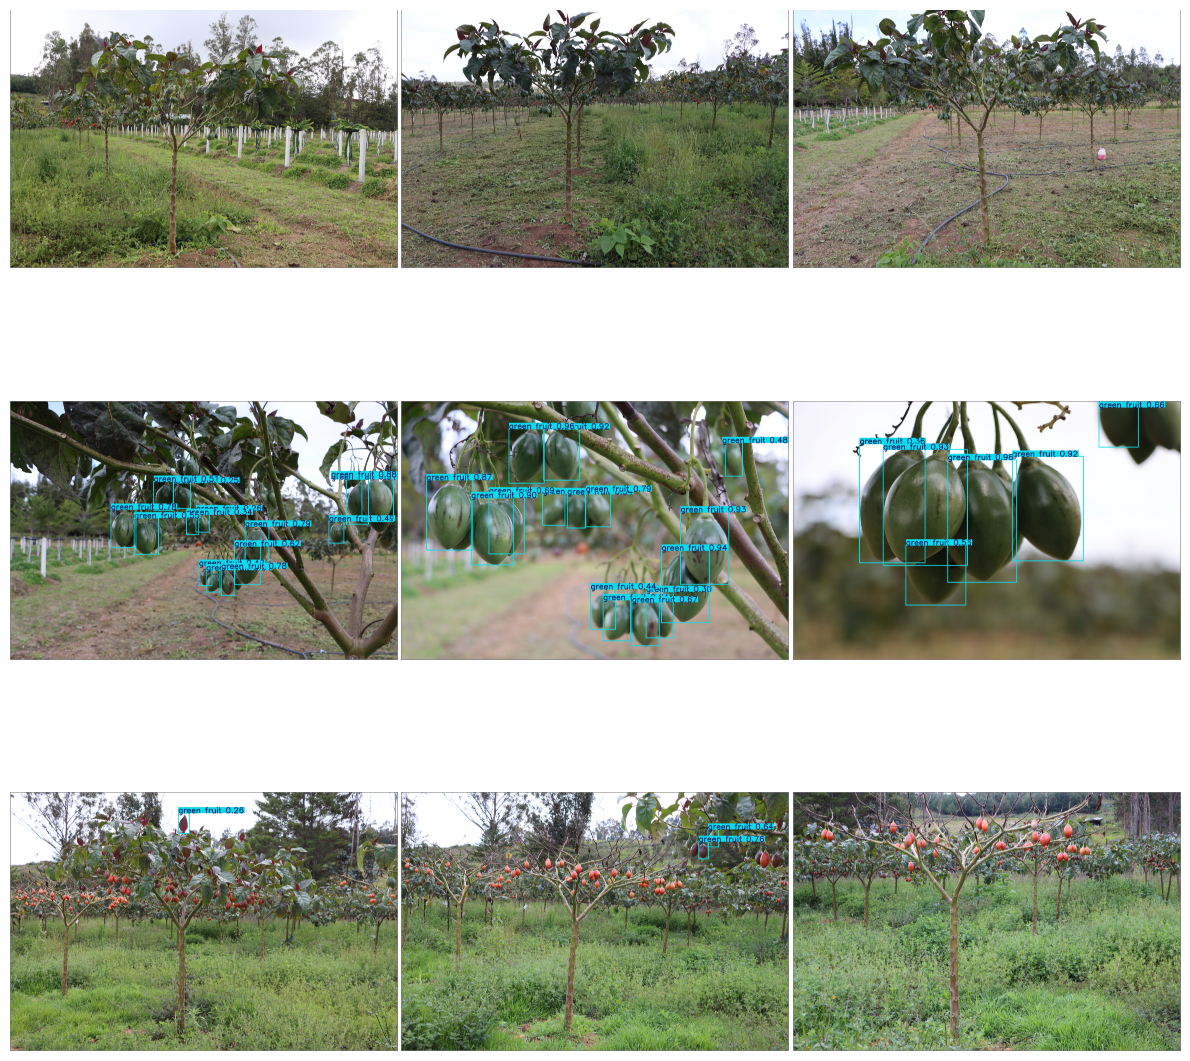

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Crear subgráficos con menos espacio entre ellos
fig, axes = plt.subplots(3, 3, figsize=(12, 12), constrained_layout=True)

# Definir el tamaño del margen (en píxeles)
margin_size = 10

# Iterar sobre los subgráficos y mostrar imágenes
for i, ax in enumerate(axes.flat):
    if i < len(preds):
        image = preds[i].plot(line_width=14, font_size=70)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convertir de BGR a RGB

        # Agregar un margen negro alrededor de la imagen
        image_with_border = cv2.copyMakeBorder(
            image, margin_size, margin_size, margin_size, margin_size,
            borderType=cv2.BORDER_CONSTANT, value=[128, 128, 128] # Color negro
        )

        ax.imshow(image_with_border)
        ax.axis("off")
    else:
        ax.axis("off")

# Ajustar los espacios automáticamente
plt.tight_layout()
plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.savefig('Predicciones.jpg', dpi=900)
plt.show()


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Verificar que 'preds' esté definido y contenga al menos un elemento
if 'preds' in locals() and isinstance(preds, list) and len(preds) > 0:
    image = preds[1].plot(line_width=25, font_size=100)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convertir de BGR a RGB

    # Mostrar la imagen predicha
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.savefig('Prediccion8.jpg', dpi=1000)
    plt.show()
else:
    print("Error: 'preds' no está definido o está vacío.")

Error: 'preds' no está definido o está vacío.
